## Load and Prepare Data

We load NBA playoff team data and select relevant columns: defensive rebounds (DREB), offensive rebounds (OREB), blocks (BLK), assists (AST), and win percentage (WIN%). These features are chosen because they are constantly referenced as key aspects of playoff performance: rebounding, defense, and playmaking.

We create two interaction features:
- **DREB × BLK**: Captures the combined effect of defensive rebounding and shot blocking, both indicative of strong interior defense.
- **OREB × AST**: Captures the synergy between offensive rebounding (second-chance opportunities) and assists (may result from these second-chances).

Interaction terms allow the model to learn joint effects that may be more predictive than individual features alone.

We standardize the features using `StandardScaler` to ensure all features contribute equally to the gradient updates and to help the Adam optimizer converge faster.

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Hyperparameters
TEST_SIZE = 0.3
LAM = 0.1                    # Regularization strength (L2 penalty)
RANDOM_STATE = 1
EPOCHS = 250
ALPHA = 0.1                 # Learning rate for Adam
BETA1 = 0.9                   # Exponential decay rate for first moment estimate
BETA2 = 0.999                 # Exponential decay rate for second moment estimate
EPSILON = 1e-8                # Small constant to prevent division by zero

# Load data
df = pd.read_csv("./data/nba_playoffs_team_data_10-26.csv")

# Keep only relevant columns and drop missing values
df = df[["DREB", "OREB", "BLK", "AST", "WIN%"]].dropna()

# Create interaction features
df["DREB_x_BLK"] = df["DREB"] * df["BLK"]
df["OREB_x_AST"] = df["OREB"] * df["AST"]

features = ["DREB_x_BLK", "OREB_x_AST"]
target = "WIN%"

X = df[features].values
y = df[target].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Hypothesis Function

We use a standard linear hypothesis:  
`h(θ, x) = θ₀ + θ₁·x₁ + θ₂·x₂`  
where θ₀ is the intercept and θ₁, θ₂ are coefficients for the two interaction features.

In [157]:
def h(theta, x):
    return theta[0] + np.dot(theta[1:], x)

## Cost Function

We use **mean squared error (MSE)** with L2 regularization (ridge regression). The cost function is:

\[
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda \sum_{j=1}^{n} \theta_j^2
\]

Regularization (λ = 0.1) helps prevent overfitting, especially given the small number of features.

In [158]:
def J(X, y, theta, lam=LAM):
    m = len(X)
    total = 0
    
    for i in range(m):
        total += (h(theta, X[i]) - y[i])**2
    
    reg = lam * np.sum(theta[1:]**2)
    
    return (total / (2*m)) + reg

## Gradients

We compute the partial derivatives of the cost function with respect to each θ.  
The gradient for the intercept has no regularization term; for the feature coefficients we add `2·λ·θⱼ`.## Gradients

In [159]:
def compute_gradients(X, y, theta, LAM):
    m = len(X)
    grads = np.zeros_like(theta)
    
    for i in range(m):
        error = h(theta, X[i]) - y[i]
        
        # Gradient for intercept
        grads[0] += error
        # Gradients for feature coefficients
        grads[1:] += error * X[i]
    
    grads = grads / m
    # Add regularization gradient (only for feature coefficients)
    grads[1:] += 2 * LAM * theta[1:]
    
    return grads

## Adam Optimizer

Adam (Adaptive Moment Estimation) combines momentum and adaptive learning rates.  
It maintains:
- **First moment (m)**: exponentially decaying average of past gradients (momentum).
- **Second moment (v)**: exponentially decaying average of past squared gradients (RMSprop-like).

Bias correction is applied at each step to account for initialization at zero.  
Adam is chosen because it converges faster and is more robust to hyperparameter choices than plain gradient descent.

In [160]:
def adam(X, y, theta, alpha=ALPHA, beta1=BETA1, beta2=BETA2, epsilon=EPSILON, iterations=EPOCHS, lam=LAM):
    m_t = np.zeros_like(theta)   # First moment vector
    v_t = np.zeros_like(theta)   # Second moment vector
    t = 0
    cost_history = []
    
    for i in range(iterations):
        t += 1
        
        # Compute gradients at current theta
        grads = compute_gradients(X, y, theta, lam)
        
        # Update biased first and second moment estimates
        m_t = beta1 * m_t + (1 - beta1) * grads
        v_t = beta2 * v_t + (1 - beta2) * (grads ** 2)
        
        # Bias correction
        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)
        
        # Parameter update
        theta = theta - alpha * m_hat / (np.sqrt(v_hat) + epsilon)
        
        # Record cost for monitoring convergence
        cost_history.append(J(X, y, theta))
    
    return theta, cost_history

## Train Model

We initialize θ to zeros and run the Adam optimizer for 250 epochs.  
The learned parameters are printed after training.

In [161]:
theta = np.zeros(len(features) + 1)

theta, cost_history = adam(X_train, y_train, theta)

print("Learned parameters:", theta)

Learned parameters: [0.40861118 0.05615837 0.01496499]


## Plot Convergence

Plotting the cost over iterations helps verify that the optimizer is converging (cost decreasing steadily).

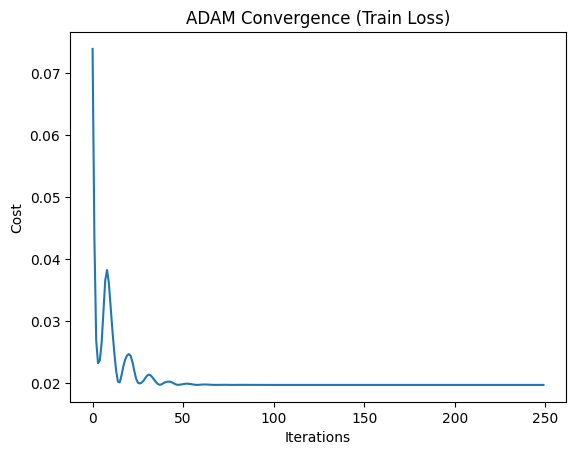

In [162]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("ADAM Convergence (Train Loss)")
plt.show()

## Predictions

The `predict` function applies the learned hypothesis to new input features.

In [163]:
def predict(X, theta):
    return np.array([h(theta, x) for x in X])

y_pred = predict(X_test, theta)

## Evaluation Metrics

We evaluate model performance using:
- **Mean Squared Error (MSE)**: Average squared difference between predicted and actual win percentages.
- **R² (coefficient of determination)**: Proportion of variance in the target explained by the model.

A low MSE and high R² indicate a good fit.

In [164]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

print("MSE:", mse(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.03802201780487389
R2: 0.11796191555820335


## Feature Importance

The absolute magnitude of the coefficients indicates the relative importance of each feature (after standardization).  
Higher absolute value = stronger influence on win percentage.

In [165]:
print("\nFeature Importance:")

importance = list(zip(features, np.abs(theta[1:])))
importance.sort(key=lambda x: x[1], reverse=True)

for name, val in importance:
    print(f"{name}: {val:.4f}")


Feature Importance:
DREB_x_BLK: 0.0562
OREB_x_AST: 0.0150


## Compare with Sklearn

We also train a standard `LinearRegression` (without regularization) to compare coefficients.  
Small differences may arise due to regularization (our model uses L2 penalty) and the Adam optimization path.

In [166]:
model = LinearRegression()
model.fit(X_train, y_train)

print("\nSklearn coefficients:", model.coef_)
print("Sklearn intercept:", model.intercept_)


Sklearn coefficients: [0.06740006 0.01492878]
Sklearn intercept: 0.40861052631578954


## Usage Example

### 3D Visualization

We plot the learned linear regression surface in 3D with the training data points.  
The plane shows the predicted win percentage as a function of the two interaction features.

### Cost vs Individual Features

We fix one feature at its mean and vary the other to see how the cost changes.  
These plots help understand the shape of the cost landscape.

### Minimum Point

We mark the learned parameters (θ₁, θ₂) on the cost landscape to confirm that Adam found a minimum.

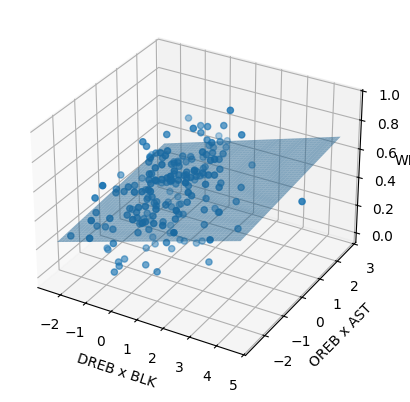

In [167]:
from mpl_toolkits.mplot3d import Axes3D

x_vals = np.linspace(X_train[:,0].min(), X_train[:,0].max(), 50)
y_vals = np.linspace(X_train[:,1].min(), X_train[:,1].max(), 50)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
Z = theta[0] + theta[1]*X_grid + theta[2]*Y_grid

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_grid, Y_grid, Z, alpha=0.5)
ax.scatter(X_train[:,0], X_train[:,1], y_train)
ax.set_xlabel("DREB x BLK")
ax.set_ylabel("OREB x AST")
ax.set_zlabel("WIN%")
plt.show()

def run_experiment(feature_set):
    """Utility function to train and evaluate on a different feature set."""
    X = df[feature_set].values
    y = df["WIN%"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    theta = np.zeros(len(feature_set) + 1)
    theta, _ = adam(X_train, y_train, theta)
    y_pred = predict(X_test, theta)
    return r2_score(y_test, y_pred)

## POV 1: DREB × BLK vs Cost

We fix OREB × AST at its mean and vary DREB × BLK, computing the cost for each value.  
This shows how the cost function behaves along one dimension.

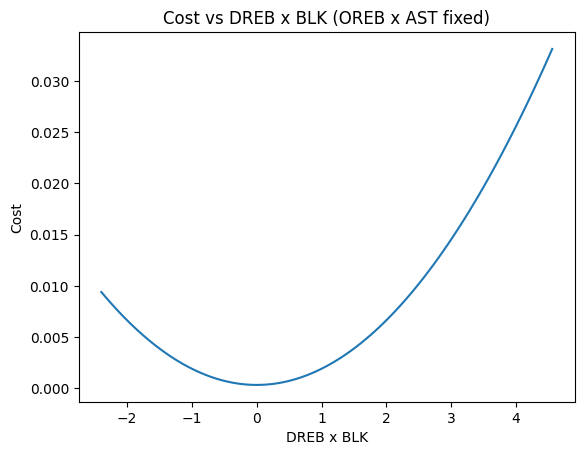

In [168]:
x1_vals = np.linspace(X_train[:,0].min(), X_train[:,0].max(), 100)
cost_vals_1 = []

# Fix second feature at its mean
x2_fixed = np.mean(X_train[:,1])

for x1 in x1_vals:
    X_temp = np.array([[x1, x2_fixed]])
    y_temp = np.array([np.mean(y_train)])  # anchor target
    
    cost = J(X_temp, y_temp, theta)
    cost_vals_1.append(cost)

plt.plot(x1_vals, cost_vals_1)
plt.xlabel("DREB x BLK")
plt.ylabel("Cost")
plt.title("Cost vs DREB x BLK (OREB x AST fixed)")
plt.show()

## POV 2: OREB × AST vs Cost

Similarly, we fix DREB × BLK at its mean and vary OREB × AST.

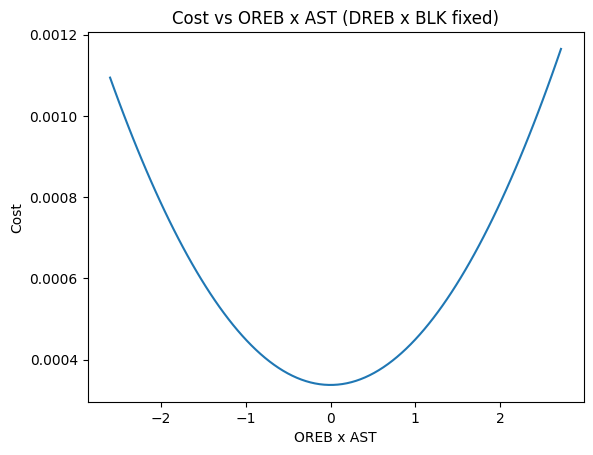

In [169]:
x2_vals = np.linspace(X_train[:,1].min(), X_train[:,1].max(), 100)
cost_vals_2 = []

# Fix first feature at its mean
x1_fixed = np.mean(X_train[:,0])

for x2 in x2_vals:
    X_temp = np.array([[x1_fixed, x2]])
    y_temp = np.array([np.mean(y_train)])
    
    cost = J(X_temp, y_temp, theta)
    cost_vals_2.append(cost)

plt.plot(x2_vals, cost_vals_2)
plt.xlabel("OREB x AST")
plt.ylabel("Cost")
plt.title("Cost vs OREB x AST (DREB x BLK fixed)")
plt.show()